<a href="https://colab.research.google.com/github/AncaraniJuanDiego/AnlisisSeriesTemporales/blob/main/TP1_y_TP2_de_Series_de_Tiempo_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 1. CARGA Y PREPARACIÓN DE DATOS
df = pd.read_csv('Datos históricos del S&P 500.csv')
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d.%m.%Y')
df.set_index('Fecha', inplace=True)
df = df.sort_index()

# Convertir la columna 'Último' a numérica, eliminando puntos como separadores de miles y reemplazando comas por puntos decimales
df['Último'] = df['Último'].str.replace('.', '', regex=False).str.replace(',', '.').astype(float)
serie = df['Último']

FileNotFoundError: [Errno 2] No such file or directory: 'Datos históricos del S&P 500.csv'

--- TEMA 1: CARACTERIZACIÓN DE LA SEÑAL ---


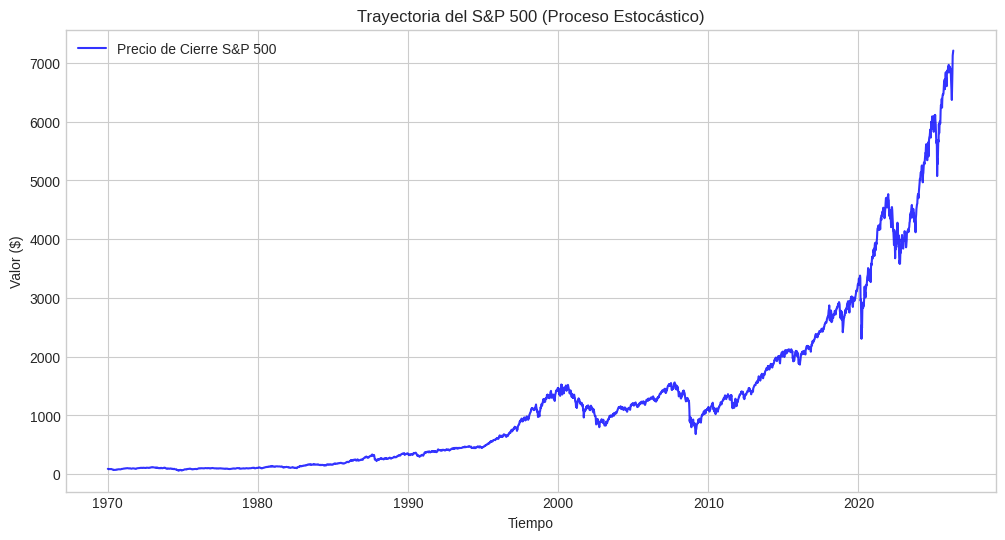

In [ ]:
print("--- TEMA 1: CARACTERIZACIÓN DE LA SEÑAL ---")
# Visualización de la trayectoria (Realización del proceso estocástico)
plt.figure()
plt.plot(serie, label='Precio de Cierre S&P 500', color='blue', alpha=0.8)
plt.title('Trayectoria del S&P 500 (Proceso Estocástico)')
plt.xlabel('Tiempo')
plt.ylabel('Valor ($)')
plt.legend()
plt.show()


--- TEMA 2: FUNCIONES DE MOMENTO Y ESTACIONARIEDAD ---


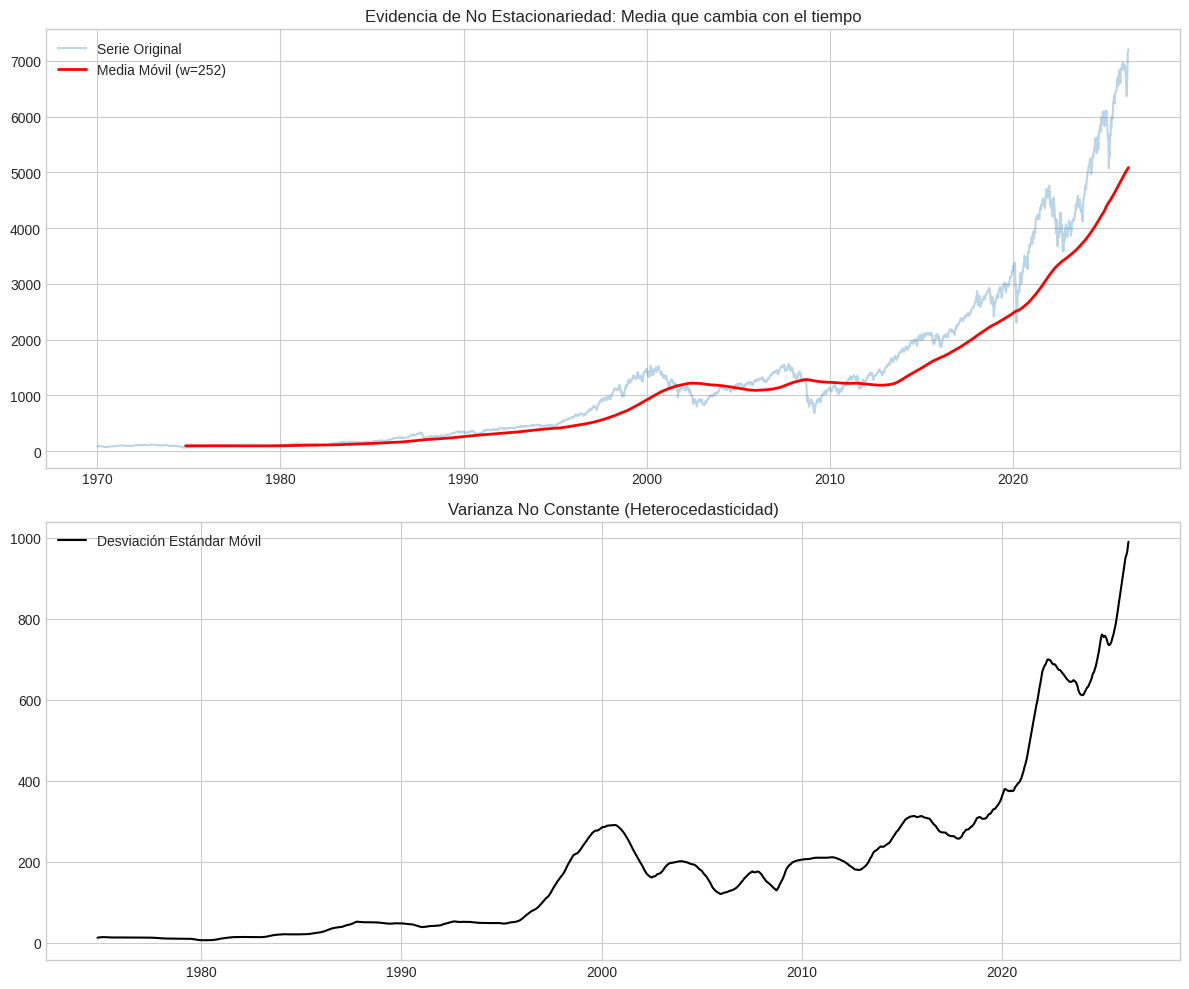

In [ ]:
print("\n--- TEMA 2: FUNCIONES DE MOMENTO Y ESTACIONARIEDAD ---")
# Cálculo de momentos móviles (Media y Desviación Estándar)
window = 252 # Ventana de un año bursátil
media_movil = serie.rolling(window=window).mean()
std_movil = serie.rolling(window=window).std()

fig, ax = plt.subplots(2, 1, figsize=(12, 10))
ax[0].plot(serie, alpha=0.3, label='Serie Original')
ax[0].plot(media_movil, color='red', linewidth=2, label=f'Media Móvil (w={window})')
ax[0].set_title('Evidencia de No Estacionariedad: Media que cambia con el tiempo')
ax[0].legend()

ax[1].plot(std_movil, color='black', label='Desviación Estándar Móvil')
ax[1].set_title('Varianza No Constante (Heterocedasticidad)')
ax[1].legend()
plt.tight_layout()
plt.show()


--- ANÁLISIS DE CORRELOGRAMAS (FAC y FACP) ---


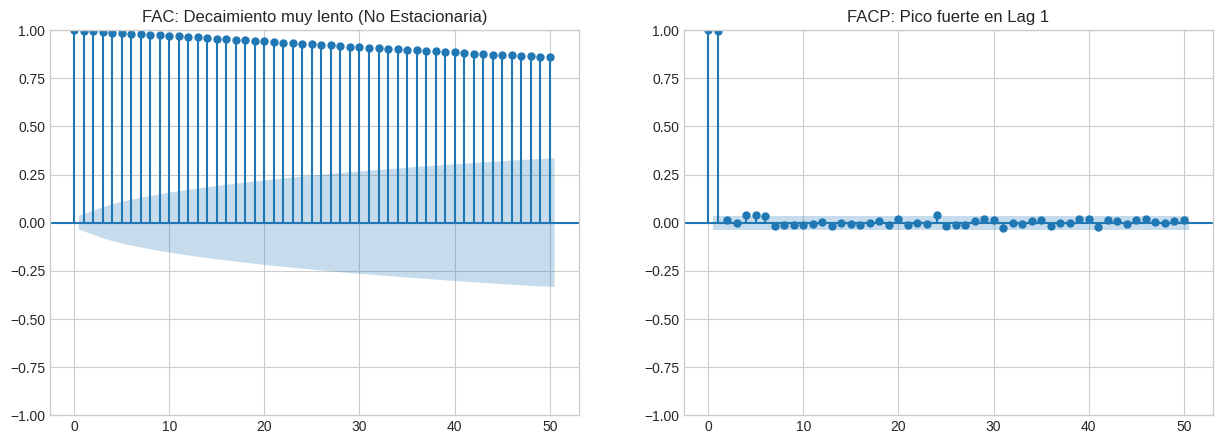

In [ ]:
print("\n--- ANÁLISIS DE CORRELOGRAMAS (FAC y FACP) ---")
# El S&P 500 suele comportarse como un Camino Aleatorio (Random Walk)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(serie, lags=50, ax=ax[0], title='FAC: Decaimiento muy lento (No Estacionaria)')
plot_pacf(serie, lags=50, ax=ax[1], title='FACP: Pico fuerte en Lag 1')
plt.show()

In [ ]:
print("\n--- TEST DE DICKEY-FULLER (SERIE ORIGINAL) ---")
# Calculamos el test sobre la serie original (sin transformar)
res_adf_orig = adfuller(serie.dropna())

print(f"Estadístico ADF: {res_adf_orig[0]:.4f}")
print(f"p-value: {res_adf_orig[1]:.4f}")
print("Conclusión: Como el p-value es mayor a 0.05, no podemos rechazar la hipótesis nula.")
print("Matemáticamente comprobado: La serie original NO es estacionaria.")


--- TEST DE DICKEY-FULLER (SERIE ORIGINAL) ---
Estadístico ADF: 5.2056
p-value: 1.0000
Conclusión: Como el p-value es mayor a 0.05, no podemos rechazar la hipótesis nula.
Matemáticamente comprobado: La serie original NO es estacionaria.



--- TEMA 3: TRANSFORMACIÓN Y RUIDO ---


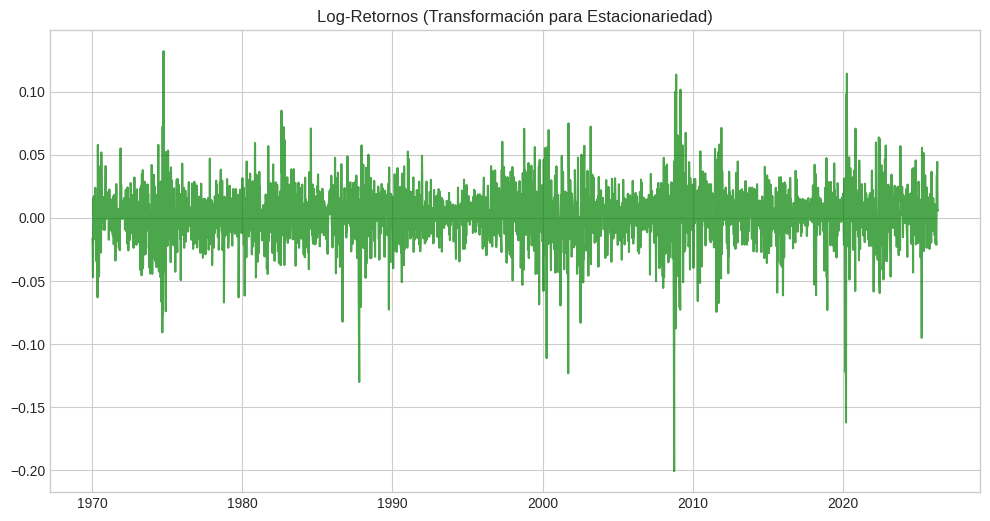

In [ ]:
print("\n--- TEMA 3: TRANSFORMACIÓN Y RUIDO ---")
# Para buscar estacionariedad y analizar si los residuos son "Ruido Blanco"
log_returns = np.log(serie).diff().dropna()
plt.figure()
plt.plot(log_returns, color='green', alpha=0.7)
plt.title('Log-Retornos (Transformación para Estacionariedad)')
plt.show()

In [ ]:
# Test de Dickey-Fuller
res_adf = adfuller(log_returns)
print(f"p-value de Dickey-Fuller: {res_adf[1]:.4f} (Si < 0.05, es estacionaria)")

p-value de Dickey-Fuller: 0.0000 (Si < 0.05, es estacionaria)



--- CORRELOGRAMAS DE LOS LOG-RETORNOS (RUIDO BLANCO) ---


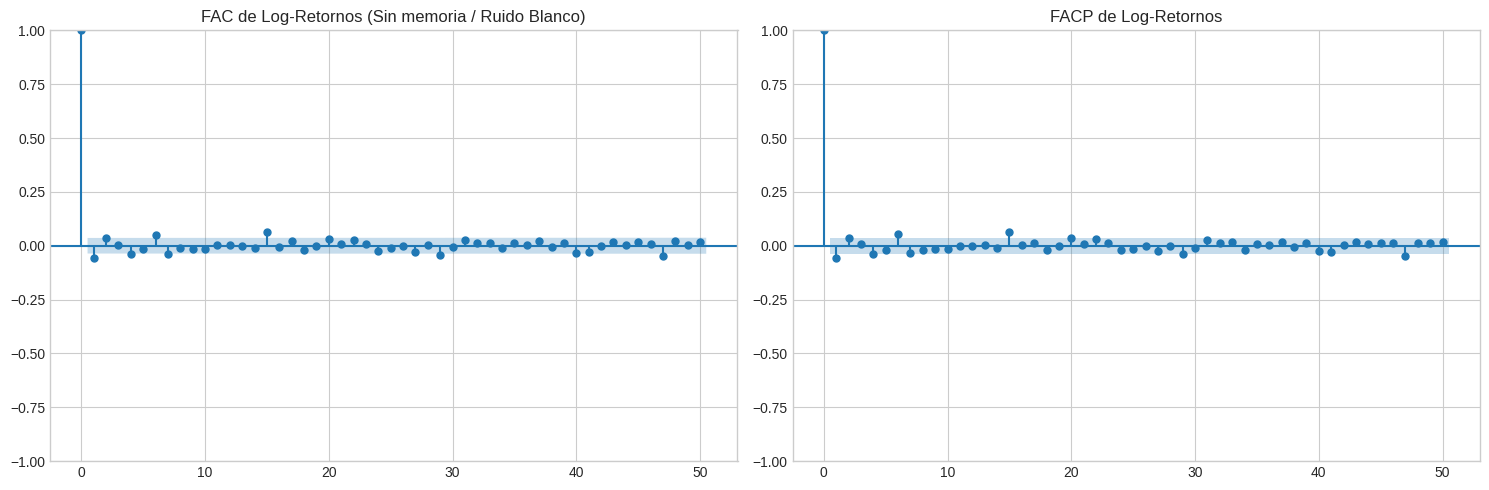

Conclusión visual: Al no haber rezagos significativos, confirmamos que los residuos se comportan como ruido blanco.


In [ ]:
print("\n--- CORRELOGRAMAS DE LOS LOG-RETORNOS (RUIDO BLANCO) ---")
# Ploteamos FAC y FACP para la serie ya transformada
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Acá se debería ver que casi ningún lag sobresale de la franja azul (intervalo de confianza)
plot_acf(log_returns, lags=50, ax=ax[0], title='FAC de Log-Retornos (Sin memoria / Ruido Blanco)')
plot_pacf(log_returns, lags=50, ax=ax[1], title='FACP de Log-Retornos')

plt.tight_layout()
plt.show()

print("Conclusión visual: Al no haber rezagos significativos, confirmamos que los residuos se comportan como ruido blanco.")


--- TEMA 4: MODELO DE DESCOMPOSICIÓN Y FILTRADO ---


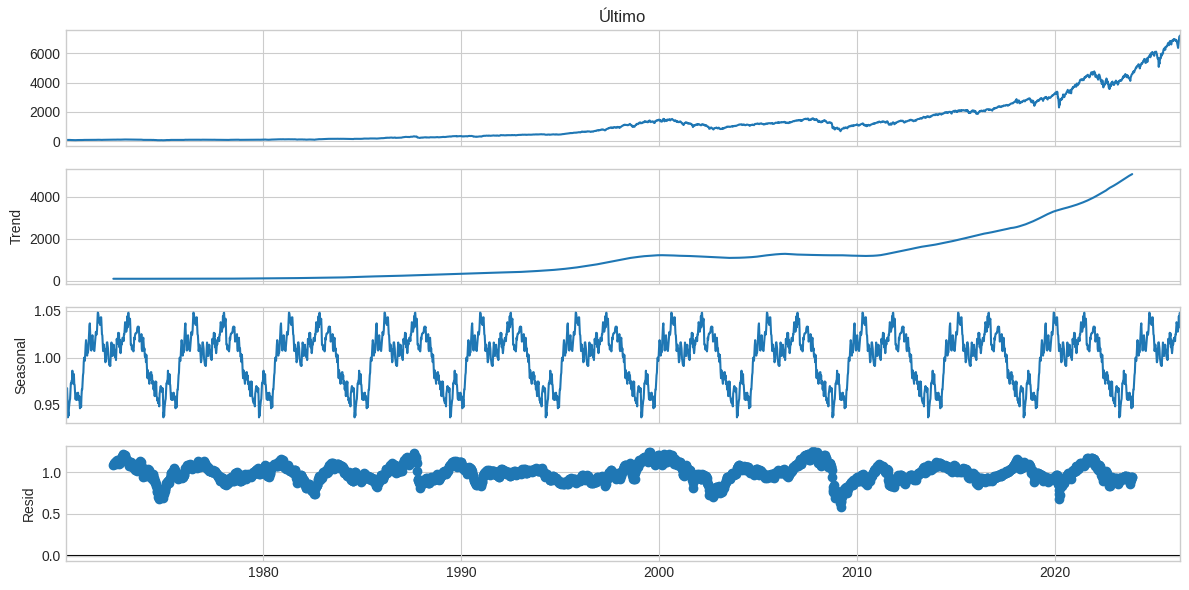

In [ ]:
print("\n--- TEMA 4: MODELO DE DESCOMPOSICIÓN Y FILTRADO ---")
# Descomposición en Tendencia, Estacionalidad y Residuo
# Usamos modelo multiplicativo por la naturaleza de los datos financieros
result = seasonal_decompose(serie, model='multiplicative', period=252)
result.plot()
plt.show()

# Trabajo Práctico Número 2

In [ ]:
print("--- TEMA 5: ANÁLISIS DE ESTACIONARIEDAD (TEST KPSS) ---")

# 1. Aplicar test KPSS a la serie original
print("--- Test KPSS - Serie Original ---")
kpss_original = kpss(serie.dropna(), regression='c', nlags='auto')
print(f"Estadístico KPSS: {kpss_original[0]:.4f}")
print(f"p-value: {kpss_original[1]:.4f}")
print(f"Valores críticos: {kpss_original[3]}")
print("-" * 30)

# 2. Aplicar test KPSS a los log-retornos
print("--- Test KPSS - Log-Retornos ---")
kpss_log_retornos = kpss(log_returns, regression='c', nlags='auto')
print(f"Estadístico KPSS: {kpss_log_retornos[0]:.4f}")
print(f"p-value: {kpss_log_retornos[1]:.4f}")
print(f"Valores críticos: {kpss_log_retornos[3]}")

--- TEMA 5: ANÁLISIS DE ESTACIONARIEDAD (TEST KPSS) ---
--- Test KPSS - Serie Original ---
Estadístico KPSS: 6.6510
p-value: 0.0100
Valores críticos: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
------------------------------
--- Test KPSS - Log-Retornos ---
Estadístico KPSS: 0.1101
p-value: 0.1000
Valores críticos: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


/tmp/ipykernel_24907/247055537.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_original = kpss(serie.dropna(), regression='c', nlags='auto')
/tmp/ipykernel_24907/247055537.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_log_retornos = kpss(log_returns, regression='c', nlags='auto')


In [ ]:
print("--- TEMA 6: SELECCIÓN DE MODELO ARMA (CRITERIOS AIC/BIC) ---\n")

resultados = []
# Probamos órdenes de p y q desde 0 hasta 3
p_valores = range(0, 4)
q_valores = range(0, 4)

print("Ajustando modelos, por favor espera...\n")

# Suppress specific ValueWarning from statsmodels by filtering UserWarning from the module
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels.tsa.base.tsa_model")

    for p in p_valores:
        for q in q_valores:
            if p == 0 and q == 0:
                continue # Omitimos el modelo sin AR ni MA (Ruido Blanco puro)

            try:
                # CORRECCIÓN: Usamos log_returns
                modelo = ARIMA(log_returns, order=(p, 0, q))
                ajuste = modelo.fit()

                # Guardamos los criterios de información
                resultados.append({
                    'Modelo': f'ARMA({p},{q})',
                    'p': p,
                    'q': q,
                    'AIC': ajuste.aic,
                    'BIC': ajuste.bic
                })
            except:
                # Si un modelo no converge, lo omitimos
                continue

# Convertir a DataFrame y ordenar por AIC
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by='AIC').reset_index(drop=True)

print("--- Ranking de Modelos según Criterios de Información ---")
print(df_resultados.head(10))

# Extraemos los mejores hiperparámetros automáticamente
mejor_modelo = df_resultados.iloc[0]
mejor_p = int(mejor_modelo['p'])
mejor_q = int(mejor_modelo['q'])

print("-" * 50)
print(f"El modelo sugerido como ganador es el {mejor_modelo['Modelo']}")
print(f"AIC: {mejor_modelo['AIC']:.2f} | BIC: {mejor_modelo['BIC']:.2f}")

--- TEMA 6: SELECCIÓN DE MODELO ARMA (CRITERIOS AIC/BIC) ---

Ajustando modelos, por favor espera...



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


--- Ranking de Modelos según Criterios de Información ---
      Modelo  p  q           AIC           BIC
0  ARMA(2,2)  2  2 -13865.354924 -13829.442018
1  ARMA(2,3)  2  3 -13863.381448 -13821.483058
2  ARMA(3,3)  3  3 -13860.814681 -13812.930806
3  ARMA(0,2)  0  2 -13859.975264 -13836.033326
4  ARMA(2,0)  2  0 -13859.583816 -13835.641878
5  ARMA(1,1)  1  1 -13858.199598 -13834.257660
6  ARMA(1,0)  1  0 -13858.128615 -13840.172162
7  ARMA(0,3)  0  3 -13857.977150 -13828.049729
8  ARMA(3,0)  3  0 -13857.689389 -13827.761967
9  ARMA(0,1)  0  1 -13857.438100 -13839.481647
--------------------------------------------------
El modelo sugerido como ganador es el ARMA(2,2)
AIC: -13865.35 | BIC: -13829.44


In [ ]:
print(f"--- TEMA 7: VALIDACIÓN TEÓRICA DEL MODELO GANADOR: {mejor_modelo['Modelo']} ---\n")

# 1. Ajustamos el modelo ganador de forma definitiva
# CORRECCIÓN: Usamos log_returns
modelo_ganador = ARIMA(log_returns, order=(mejor_p, 0, mejor_q))
ajuste_final = modelo_ganador.fit()

# 2. Extraemos los coeficientes
ar_coefs = ajuste_final.arparams
ma_coefs = ajuste_final.maparams

print("--- Coeficientes del modelo ---")
print(f"AR (phi): {ar_coefs}")
print(f"MA (theta): {ma_coefs}\n")

# 3. Extraemos las raíces de los polinomios y calculamos su módulo (valor absoluto)
ar_raices = ajuste_final.arroots
ma_raices = ajuste_final.maroots

print("--- Validación Teórica (El módulo debe ser > 1) ---")
if mejor_p > 0:
    print("Raíces del polinomio AR (Verifica Causalidad y Estabilidad):")
    for i, raiz in enumerate(ar_raices):
        print(f"  Raíz {i+1}: {raiz:.4f} | Módulo: {np.abs(raiz):.4f}")

if mejor_q > 0:
    print("\nRaíces del polinomio MA (Verifica Invertibilidad):")
    for i, raiz in enumerate(ma_raices):
        print(f"  Raíz {i+1}: {raiz:.4f} | Módulo: {np.abs(raiz):.4f}")

--- TEMA 7: VALIDACIÓN TEÓRICA DEL MODELO GANADOR: ARMA(2,2) ---



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


--- Coeficientes del modelo ---
AR (phi): [-0.53423998 -0.66014884]
MA (theta): [0.47813579 0.67468314]

--- Validación Teórica (El módulo debe ser > 1) ---
Raíces del polinomio AR (Verifica Causalidad y Estabilidad):
  Raíz 1: -0.4046-1.1624j | Módulo: 1.2308
  Raíz 2: -0.4046+1.1624j | Módulo: 1.2308

Raíces del polinomio MA (Verifica Invertibilidad):
  Raíz 1: -0.3543-1.1647j | Módulo: 1.2174
  Raíz 2: -0.3543+1.1647j | Módulo: 1.2174


In [ ]:
from statsmodels.tsa.ar_model import AutoReg
import scipy.stats as stats

--TEMA 8: AUTOMODELADO (AR(p))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


Comportamiento de la serie en los próximos 30 periodos, según el modelo: 
2026-05-03    7212.996060
2026-05-10    7203.484284
2026-05-17    7198.092342
2026-05-24    7239.176776
2026-05-31    7241.444072
Freq: W-SUN, dtype: float64


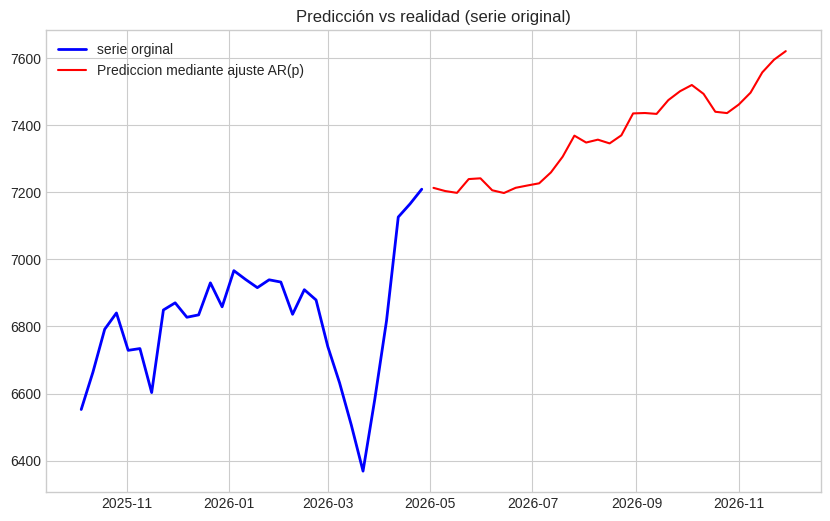

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


Comportamiento de la serie diferenciada en los próximos 30 periodos, según el modelo: 
2026-05-03    0.001852
2026-05-10    0.002344
2026-05-17   -0.000927
2026-05-24    0.003299
2026-05-31    0.001618
Freq: W-SUN, dtype: float64


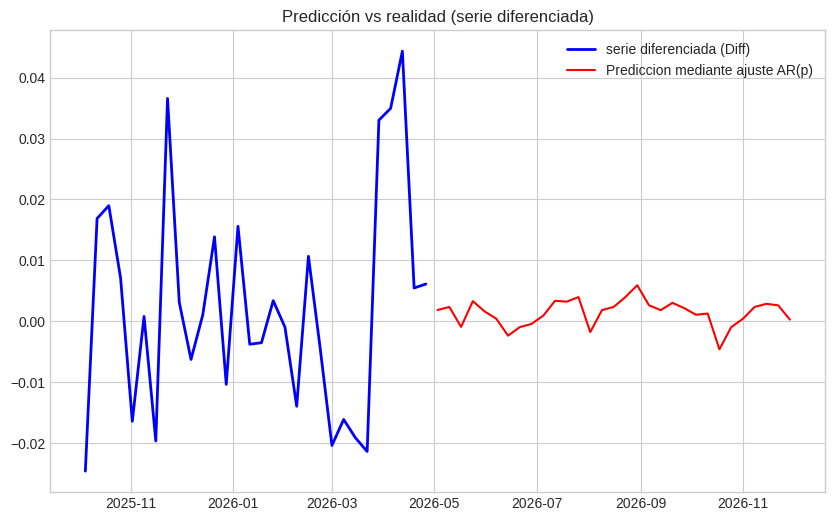

In [ ]:
print('--TEMA 8: AUTOMODELADO (AR(p))')

lags = 50 #Se seleccionan 50 retardos para capturar la inercia de los últimos dos meses de negociación.
model_AR = AutoReg(serie.dropna(), lags = lags, old_names = False)
model_AR_Fit = model_AR.fit()

prediction_series = model_AR_Fit.predict(start = len(serie), end = len(serie) + 30, dynamic = False)
print('Comportamiento de la serie en los próximos 30 periodos, según el modelo: ')
print(prediction_series.head(5))

last_reals_series = serie.tail(30)

#Grafico de predicción vs real

plt.figure(figsize = (10,6))
plt.plot(last_reals_series.index, last_reals_series.values, color = 'blue' , label = 'serie orginal', linewidth = 2)
plt.plot(prediction_series.index, prediction_series.values,  color = 'red', label = 'Prediccion mediante ajuste AR(p)')
plt.title('Predicción vs realidad (serie original)')
plt.legend()
plt.show()


#Ahora con la serie diferenciada

lags = 50
model_AR_Diff = AutoReg(log_returns.dropna(), lags = lags, old_names = False)
model_AR_Diff_Fit = model_AR_Diff.fit()

prediction_serieDiff = model_AR_Diff_Fit.predict(start = len(log_returns), end = len(log_returns) + 30, dynamic = False)
print('Comportamiento de la serie diferenciada en los próximos 30 periodos, según el modelo: ')
print(prediction_serieDiff.head(5))

last_reals_serieDiff = log_returns.tail(30)
plt.figure(figsize = (10,6))
plt.plot(last_reals_serieDiff.index, last_reals_serieDiff.values, color = 'blue' , label = 'serie diferenciada (Diff)', linewidth = 2)
plt.plot(prediction_serieDiff.index, prediction_serieDiff.values,  color = 'red', label = 'Prediccion mediante ajuste AR(p)')
plt.title('Predicción vs realidad (serie diferenciada)')
plt.legend()
plt.show()

--TEMA 9: MEDIA MOVIL(MA(q)) CHEQUEO DE ERRORES--


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


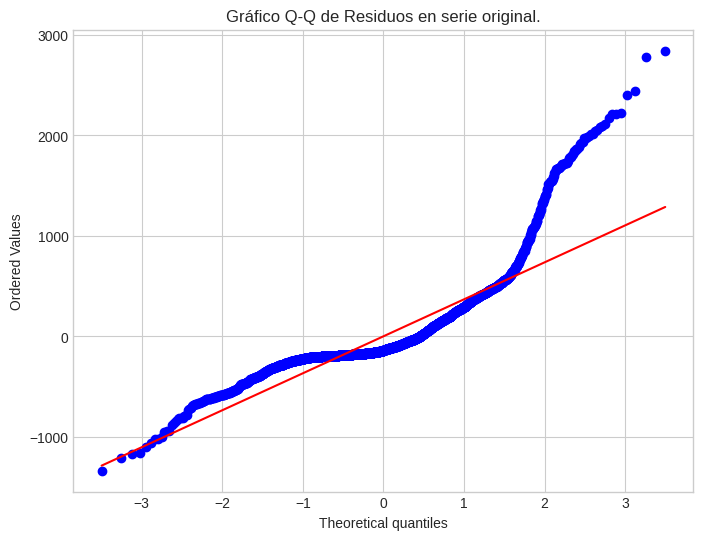

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


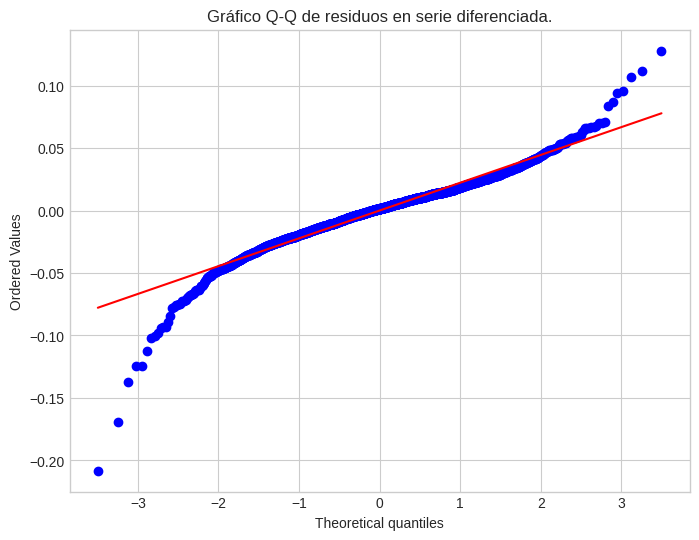

In [ ]:
print('--TEMA 9: MEDIA MOVIL(MA(q)) CHEQUEO DE ERRORES--')


model_MA = ARIMA(serie.dropna(), order = (0,0, q))
model_MA_Fit = model_MA.fit()
residuals_sr = model_MA_Fit.resid

#Visualizar errores
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
stats.probplot(residuals_sr, dist="norm", plot=ax)
plt.title('Gráfico Q-Q de Residuos en serie original.')
plt.show()


#orden 1 → la serie ya es estacionaria
q = 1

model_MA = ARIMA(log_returns.dropna(), order = (0,0, q))
model_MA_Fit = model_MA.fit()
residuals = model_MA_Fit.resid

#Visualizar errores
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
stats.probplot(residuals, dist="norm", plot=ax)
plt.title('Gráfico Q-Q de residuos en serie diferenciada.')
plt.show()

La visualización de los residuos permite confirmar que el modelo MA ha capturado la estructura de autocorrelación de corto plazo. Al principio, cuando trabajamos con la serie original, el modelo parece cometer más errores de predicción, principalmente se queda corto al principio, se equivoca por poco a la mitad y subestima bastante al final.

Cuando diferenciamos comete menos errores (esto por la poca variabilidad entre días y estacionariedad presente), solo cometiendo errores mínimos a escalas entre (-0.10,-0.20) y al final igual.

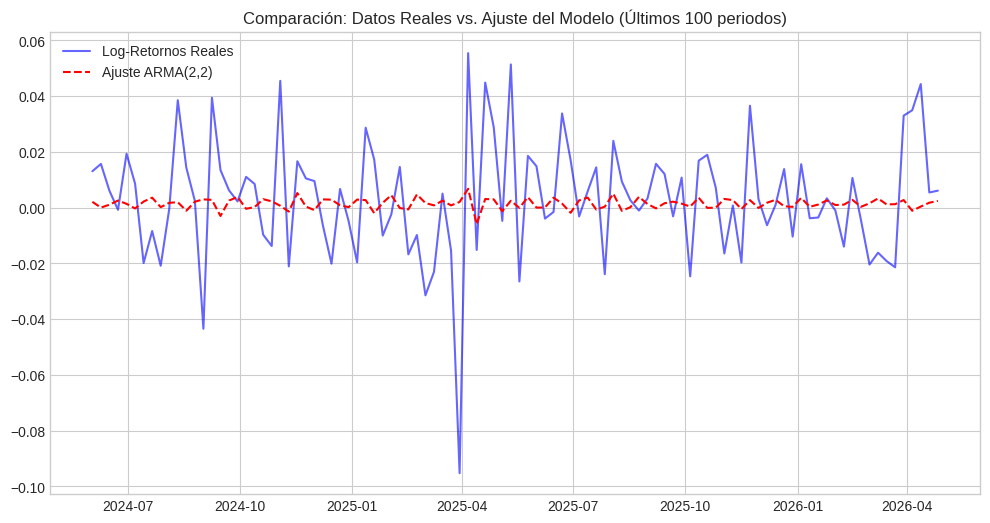

In [ ]:
# 2. Ajuste del Modelo vs Realidad (Zoom en los últimos 100 datos)
plt.figure(figsize=(12, 6))
plt.plot(log_returns.iloc[-100:], label='Log-Retornos Reales', color='blue', alpha=0.6)
plt.plot(ajuste_final.fittedvalues.iloc[-100:], label='Ajuste ARMA(2,2)', color='red', linestyle='--')
plt.title('Comparación: Datos Reales vs. Ajuste del Modelo (Últimos 100 periodos)')
plt.legend()
plt.show()